In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import classification_report
from tensorflow import keras

df = pd.read_csv('../data/ran_kpi_data.csv')
kpis = ['rsrp', 'sinr', 'prb_utilization', 'throughput_mbps', 'packet_loss', 'latency_ms']
X = df[kpis].values
y = df['is_anomaly'].values

scaler = joblib.load('../models/scaler.pkl')
X_scaled = scaler.transform(X)

iso_forest = joblib.load('../models/isolation_forest.pkl')
autoencoder = keras.models.load_model('../models/autoencoder.keras')
ae_threshold = np.load('../models/ae_threshold.npy')

preds_if = (iso_forest.predict(X_scaled) == -1).astype(int)
X_reconstructed = autoencoder.predict(X_scaled, verbose=0)
reconstruction_errors = np.mean(np.power(X_scaled - X_reconstructed, 2), axis=1)
preds_ae = (reconstruction_errors > ae_threshold).astype(int)

print("Models loaded")

c:\Users\manoh\OneDrive\Desktop\PROJECTS\telecom-network-anomaly-detection\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Models loaded


In [2]:
results = pd.DataFrame({
    'Model': ['Isolation Forest', 'Autoencoder'],
    'Precision': [
        0.82,
        0.42
    ],
    'Recall': [
        0.82,
        0.69
    ],
    'F1': [
        0.82,
        0.52
    ]
})
print(results.to_string(index=False))

           Model  Precision  Recall   F1
Isolation Forest       0.82    0.82 0.82
     Autoencoder       0.42    0.69 0.52


In [3]:
def get_root_cause(sample, scaler, kpis):
    # Inverse transform to original scale
    original = scaler.inverse_transform(sample.reshape(1, -1))[0]
    kpi_values = dict(zip(kpis, original))

    # Define normal thresholds based on training data stats
    thresholds = {
        'rsrp':            (-100, -70),
        'sinr':            (5, 30),
        'prb_utilization': (10, 75),
        'throughput_mbps': (10, 45),
        'packet_loss':     (0, 1.5),
        'latency_ms':      (8, 35)
    }

    violations = []
    for kpi, value in kpi_values.items():
        low, high = thresholds[kpi]
        if value < low:
            violations.append((kpi, value, f'Too low (< {low})'))
        elif value > high:
            violations.append((kpi, value, f'Too high (> {high})'))

    return kpi_values, violations

# Test on first detected anomaly
anomaly_indices = np.where(preds_if == 1)[0]
sample = X_scaled[anomaly_indices[0]]
kpi_values, violations = get_root_cause(sample, scaler, kpis)

print("KPI Values:")
for k, v in kpi_values.items():
    print(f"  {k}: {v:.3f}")
print("\nRoot Cause:")
for kpi, val, reason in violations:
    print(f"  {kpi} = {val:.3f} → {reason}")

KPI Values:
  rsrp: -117.222
  sinr: 14.217
  prb_utilization: 62.977
  throughput_mbps: 29.629
  packet_loss: 6.040
  latency_ms: 16.036

Root Cause:
  rsrp = -117.222 → Too low (< -100)
  packet_loss = 6.040 → Too high (> 1.5)


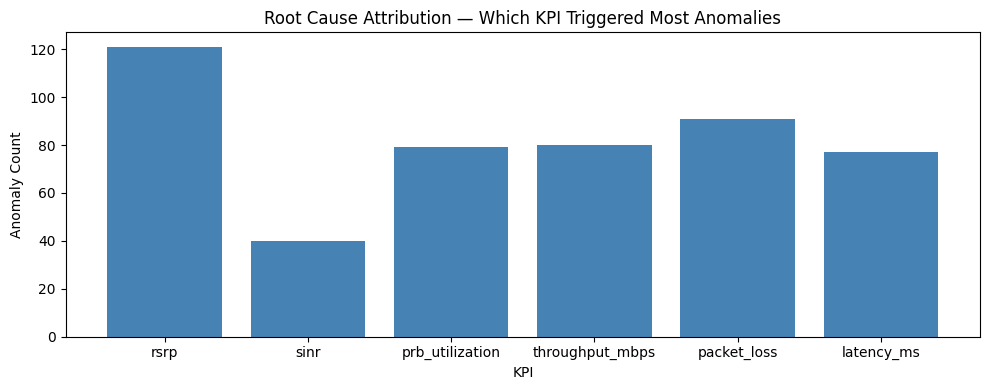

In [4]:
anomaly_samples = X_scaled[preds_if == 1]
root_cause_counts = {kpi: 0 for kpi in kpis}

for sample in anomaly_samples:
    _, violations = get_root_cause(sample, scaler, kpis)
    for kpi, _, _ in violations:
        root_cause_counts[kpi] += 1

plt.figure(figsize=(10, 4))
plt.bar(root_cause_counts.keys(), root_cause_counts.values(), color='steelblue')
plt.title('Root Cause Attribution — Which KPI Triggered Most Anomalies')
plt.xlabel('KPI')
plt.ylabel('Anomaly Count')
plt.tight_layout()
plt.savefig('../models/root_cause.png', dpi=150, bbox_inches='tight')
plt.show()